# FASE 1 — Exploração de Dados

Dataset: PCOS_infertility.csv

Objetivo: carregar, explorar e entender os dados antes do pré-processamento.

## O problema: Síndrome dos Ovários Policísticos (PCOS)

A Síndrome dos Ovários Policísticos (PCOS) é um distúrbio hormonal que afeta entre 6% e 12% das mulheres em idade reprodutiva, sendo uma das principais causas de infertilidade feminina. A síndrome é caracterizada por três critérios diagnósticos (Consenso de Rotterdam, 2003): hiperandrogenismo (excesso de hormônios masculinos), disfunção ovulatória e ovários com morfologia policística ao ultrassom — sendo necessários pelo menos dois dos três para o diagnóstico.

Além do impacto reprodutivo, a PCOS está associada a complicações metabólicas de longo prazo: resistência à insulina, diabetes tipo 2, doenças cardiovasculares e distúrbios psicológicos como ansiedade e depressão. O diagnóstico precoce é fundamental para o manejo adequado, mas é frequentemente tardio — estima-se que até 70% das mulheres com PCOS não são diagnosticadas.

**Por que usar Machine Learning?** O diagnóstico de PCOS envolve a análise simultânea de múltiplas variáveis clínicas, hormonais e de imagem. Um modelo de classificação pode servir como **ferramenta de apoio à triagem**, identificando pacientes com maior probabilidade de ter a síndrome a partir de exames de rotina e acelerando o encaminhamento para confirmação clínica. O objetivo não é substituir o médico, mas sim reduzir o tempo até o diagnóstico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carregando o dataset

In [2]:
# Carrega o CSV e mostra quantas linhas e colunas tem o dataset
df = pd.read_csv('../data/PCOS_infertility.csv')
print(f'{df.shape[0]} linhas, {df.shape[1]} colunas')

541 linhas, 6 colunas


In [3]:
# Mostra as 5 primeiras linhas para entender a estrutura da tabela
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),AMH(ng/mL)
0,1,10001,0,1.99,1.99,2.07
1,2,10002,0,60.80,1.99,1.53
2,3,10003,1,494.08,494.08,6.63
3,4,10004,0,1.99,1.99,1.22
4,5,10005,0,801.45,801.45,2.26


In [4]:
# Estatísticas descritivas: count, média, desvio padrão, min, quartis e max de cada coluna numérica
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL)
count,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,10271.000000,0.327172,664.549235,238.229518
std,156.317519,156.317519,0.469615,3348.920576,1603.826221
min,1.000000,10001.000000,0.000000,1.300000,0.110417
25%,136.000000,10136.000000,0.000000,1.990000,1.990000
50%,271.000000,10271.000000,0.000000,20.000000,1.990000
75%,406.000000,10406.000000,1.000000,297.210000,97.630000
max,541.000000,10541.000000,1.000000,32460.970000,25000.000000


In [5]:
# Mostra tipo de cada coluna (int, float, object) e quantidade de valores não nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3     I   beta-HCG(mIU/mL)  541 non-null    float64
 4   II    beta-HCG(mIU/mL)  541 non-null    float64
 5   AMH(ng/mL)              541 non-null    str    
dtypes: float64(2), int64(3), str(1)
memory usage: 25.5 KB


## 2. Tratamento de Dados

### 2.1 Verificação de valores nulos

In [6]:
# Lista apenas as colunas que possuem valores nulos e quantos são
print('Valores nulos por coluna:')
nulos = df.isnull().sum()
nulos[nulos > 0]

Valores nulos por coluna:


Series([], dtype: int64)

### 2.2 Remoção de colunas irrelevantes e conversão de tipos (object -> numérico)

Antes de imputar os nulos, dois passos de preparação são necessários:
- Remover `Sl. No` e `Patient File No.`: colunas de identificação sem valor preditivo
- Converter `AMH(ng/mL)` de `object` para numérico (pode conter texto misturado)

In [7]:
# Remove colunas de identificação (sem valor preditivo)
cols_to_drop = ['Sl. No', 'Patient File No.']
cols_exist = [c for c in cols_to_drop if c in df.columns]
if cols_exist:
    df = df.drop(columns=cols_exist)
    print(f'Colunas removidas: {cols_exist}')

# Converte colunas do tipo object para numérico
# errors='coerce': valores que não podem ser convertidos viram NaN
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'Coluna "{col}" convertida para numérico.')

print(f'\n{df.shape[0]} linhas, {df.shape[1]} colunas')
print('\nNulos após preparação:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')

Colunas removidas: ['Sl. No', 'Patient File No.']
Coluna "AMH(ng/mL)" convertida para numérico.

541 linhas, 4 colunas

Nulos após preparação:
AMH(ng/mL)    1
dtype: int64


### 2.3 Imputação com SimpleImputer

Utiliza a mediana de cada coluna para substituir os valores nulos.

In [8]:
from sklearn.impute import SimpleImputer

colunas_nulas = df.columns[df.isnull().any()].tolist()

if colunas_nulas:
    print('Colunas que serão imputadas:', colunas_nulas)
    # strategy='median': substitui cada NaN pela mediana da coluna
    imputer = SimpleImputer(strategy='median')
    df[colunas_nulas] = imputer.fit_transform(df[colunas_nulas])
    print(f'\nNulos restantes após SimpleImputer: {df.isnull().sum().sum()}')
else:
    print('Nenhuma coluna com valores nulos para imputar.')

print(f'Shape final: {df.shape}')

Colunas que serão imputadas: ['AMH(ng/mL)']

Nulos restantes após SimpleImputer: 0
Shape final: (541, 4)


### 2.4 Verificação final

In [9]:
nulos_final = df.isnull().sum()
if nulos_final.sum() == 0:
    print('Nenhum valor nulo restante no dataset.')
else:
    print('Nulos restantes:')
    print(nulos_final[nulos_final > 0])

Nenhum valor nulo restante no dataset.


## 3. Distribuição da variável target (PCOS: sim/não)

In [10]:
# Contagem e proporção da variável alvo: quantas pacientes têm PCOS (1) e quantas não têm (0)
print('Distribuição da target:')
print(df['PCOS (Y/N)'].value_counts())
print(f'\nProporção: {df["PCOS (Y/N)"].value_counts(normalize=True).round(3)}')

Distribuição da target:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Proporção: PCOS (Y/N)
0    0.673
1    0.327
Name: proportion, dtype: float64


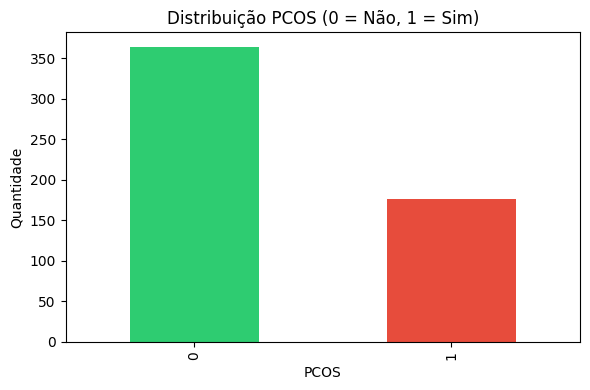

In [11]:
# Gráfico de barras para visualizar o balanceamento entre as classes
fig, ax = plt.subplots(figsize=(6, 4))
df['PCOS (Y/N)'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribuição PCOS (0 = Não, 1 = Sim)')
ax.set_xlabel('PCOS')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

## 4. Estatísticas por classe

In [12]:
# Média de cada feature separada por classe (PCOS vs não-PCOS) para identificar diferenças
df.groupby('PCOS (Y/N)').mean(numeric_only=True).T

PCOS (Y/N),0,1
I beta-HCG(mIU/mL),728.982437,532.042537
II beta-HCG(mIU/mL),223.975137,267.543613
AMH(ng/mL),4.539184,7.844633


## 5. Histogramas das features por classe

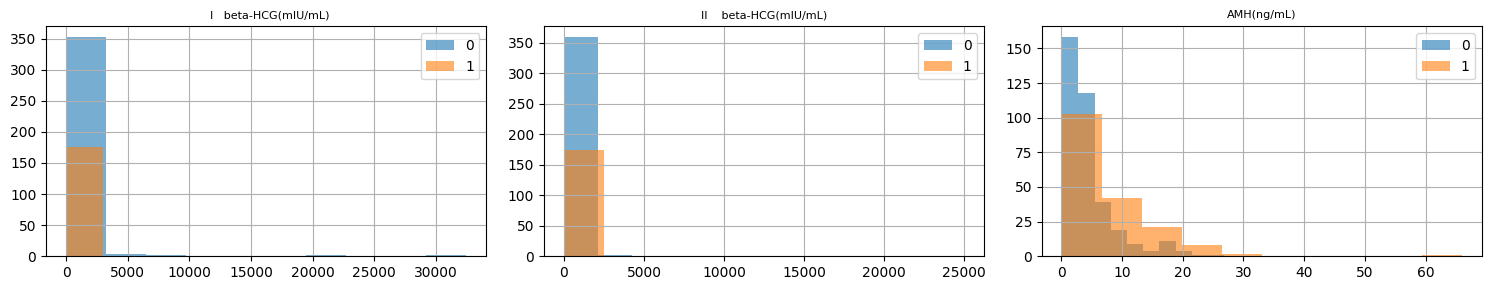

In [13]:
# Histogramas de todas as features numéricas, coloridos por classe
# Ajuda a visualizar se a distribuição de uma feature é diferente entre PCOS e não-PCOS
features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
features_numericas = [f for f in features_numericas if f != 'PCOS (Y/N)']

fig, axes = plt.subplots(nrows=len(features_numericas) // 4 + 1, ncols=4, figsize=(20, len(features_numericas)))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    df.groupby('PCOS (Y/N)')[col].hist(alpha=0.6, ax=axes[i], legend=True)
    axes[i].set_title(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Discussão

### Contexto deste dataset

Este arquivo (`PCOS_infertility.csv`) é um **complemento** ao dataset principal (`PCOS_data_without_infertility.xlsx`). Enquanto o dataset principal contém 42 features clínicas, este possui apenas 3 variáveis preditivas — os marcadores hormonais `I beta-HCG`, `II beta-HCG` e `AMH` — além da variável target `PCOS (Y/N)`. Ambos compartilham as mesmas 541 pacientes.

### Balanceamento das classes

A distribuição da target é idêntica ao dataset principal: 67,3% sem PCOS e 32,7% com PCOS. Esse desbalanceamento moderado (proporção ~2:1) exigirá atenção na modelagem para garantir que o classificador não ignore a classe minoritária.

### Análise das features

- **AMH — Hormônio Anti-Mülleriano** (+73%): a feature com maior diferença entre classes neste dataset. Pacientes com PCOS apresentam média de 7,84 ng/mL contra 4,54 do grupo controle. Esse resultado é clinicamente coerente — o AMH elevado está associado a um maior número de folículos antrais, característica central da síndrome.
- **I beta-HCG** (-27%): média ligeiramente menor no grupo PCOS (532 vs 729 mIU/mL). O beta-HCG é primariamente um marcador de gravidez, e essa diferença pode refletir taxas de gravidez distintas entre os grupos.
- **II beta-HCG** (+19%): diferença pequena e na direção oposta à primeira medição. A variação entre as duas medições pode indicar diferenças no momento da coleta ou na dinâmica hormonal entre os grupos.

### Valores ausentes

O dataset original não apresentava valores nulos. Porém, a coluna `AMH(ng/mL)` estava armazenada como texto (`str`). Após a conversão para numérico, 1 valor que não pôde ser convertido gerou um `NaN`, tratado via imputação pela mediana.

### Outliers

Os histogramas revelam que tanto `I beta-HCG` quanto `II beta-HCG` possuem distribuições extremamente assimétricas — a grande maioria dos valores está concentrada próxima a zero, com uma cauda longa para a direita (valores chegam a 32.460 e 25.000 mIU/mL respectivamente). Isso indica a presença de outliers significativos. O `AMH` também é assimétrico, porém em menor grau.

### Limitação

Com apenas 3 features, este dataset isoladamente pode não ter poder preditivo suficiente para uma boa classificação. Seu valor principal está na combinação com o dataset completo, onde essas variáveis hormonais complementam as features clínicas, antropométricas e de sintomas.